# Mapping the Parks

Using data from [nycopendata](https://nycopendata.socrata.com/Recreation/Parks-Properties/enfh-gkve/about_data), specifically the `shape` column, let's see if we can create map visualizations.

In [21]:
import datetime
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.eda import COLORS, COLORS_DICT, get_parks_data, nymyc_cmap, nymyc_cmap_r, read_all_csvs

# mpl.colormaps.register(cmap=nymyc_cmap)
# mpl.colormaps.register(cmap=nymyc_cmap_r)
# nymyc_palette = sns.set_palette(sns.color_palette(COLORS))

# Show all columns in DataFrames
pd.set_option('display.max_columns', None)

# Auto-reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Axes: >

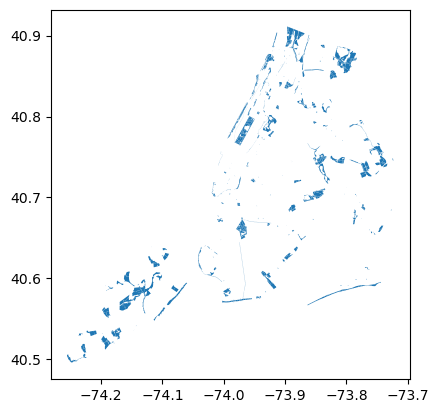

In [3]:
parks = gpd.read_file('../data/Parks Zones_20241027/')
parks.plot()

Got it plotting! But definitely need borough boundaries or something else in the background--can't just have parks floating in space.

<Axes: >

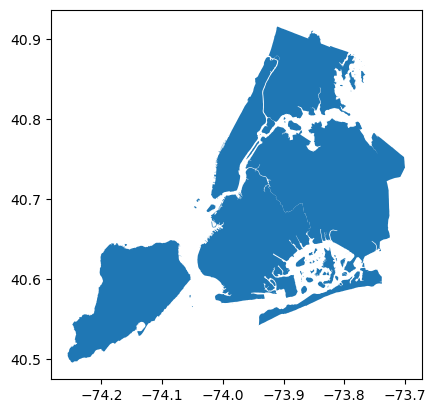

In [4]:
boroughs = gpd.read_file('../data/Borough Boundaries/')
boroughs.plot()

Now to combine them...

<Axes: >

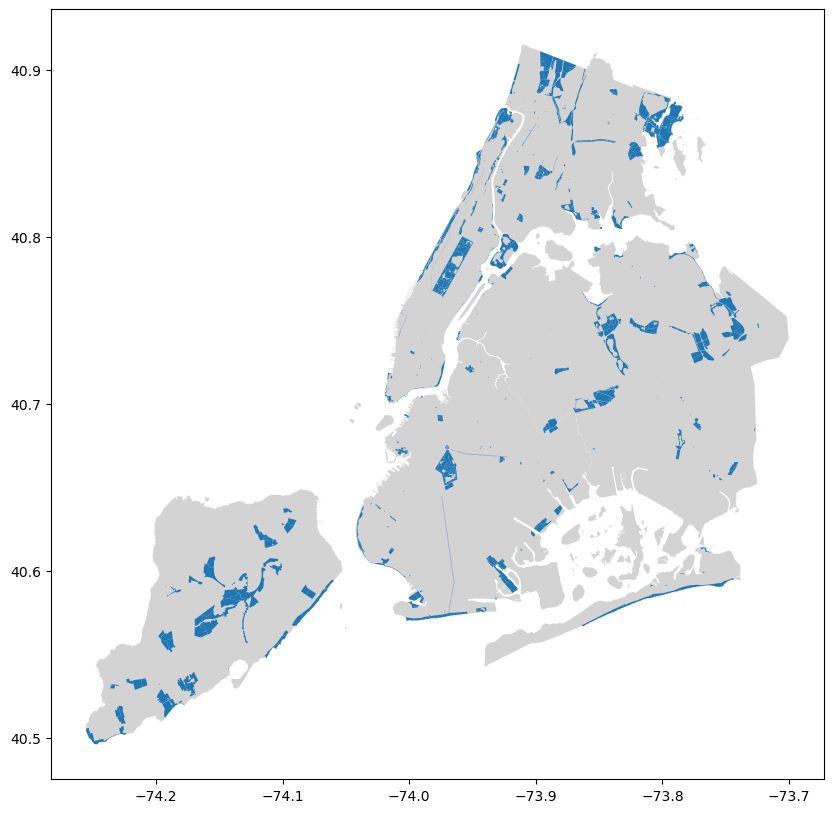

In [5]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks.plot(ax=ax)

Success! Now to get some data in there...

In [22]:
parks_data = get_parks_data()
parks_data.head()

,MushroomID,NewToPark,NewToCity,ParkName,Borough,City,State,BroadGroupID,Genus,Species,BroadGroupName,FullName
0,300,y,y,Central Park,Manhattan,New York City,NY,3.0,Hortiboletus,campestris,Boletes,Hortiboletus campestris
1,2329,y,y,Central Park,Manhattan,New York City,NY,3.0,Boletus,subvelutipes-complex,Boletes,Boletus subvelutipes-complex
2,3,y,y,Central Park,Manhattan,New York City,NY,3.0,Cyanoboletus,pulverulentus,Boletes,Cyanoboletus pulverulentus
3,4,y,y,Central Park,Manhattan,New York City,NY,3.0,Gyroporus,castaneus,Boletes,Gyroporus castaneus
4,5,y,y,Central Park,Manhattan,New York City,NY,3.0,Tylopilus,ferrugineus,Boletes,Tylopilus ferrugineus


In [23]:
parks_data.groupby('ParkName').BroadGroupName.nunique().reset_index().head()

,ParkName,BroadGroupName
0,Alley Pond Park,17
1,Beech Brook,17
2,Central Park,15
3,Clove Lakes Park,16
4,Collis P. Huntingdon Park,14


In [24]:
parks_data.groupby('ParkName').Species.nunique().reset_index().head()

,ParkName,Species
0,Alley Pond Park,397
1,Beech Brook,401
2,Central Park,326
3,Clove Lakes Park,315
4,Collis P. Huntingdon Park,233


In [25]:
# Check for parks that don't match across datasets
nymyc_parks = list(parks_data['ParkName'].unique())
nymyc_parks.sort()
nyc_parks = list(parks['propname'].unique())
nyc_parks.sort()
print('Parks in walks list but not in NYC data:')
print([p for p in nymyc_parks if p not in nyc_parks])
print('\n')
print('Parks in NYC data but not in walks list:')
print([p for p in nyc_parks if p not in nymyc_parks])

Parks in walks list but not in NYC data:
['Beech Brook', 'Collis P. Huntingdon Park', 'Depew Park', "Devil's Den Preserve", 'Fahnestock State Park', 'Green-Wood Cemetery', 'High Rock Park', 'Manitou Point Preserve', 'Mt. Lakes Park', 'Norvin Green State Forest', 'Putnam Memorial State Park', 'South Mountain Reservation', 'Stony Brook, Harriman', 'Stony Brook, Long Island', 'Tallman State Park', 'Untermeyer Gardens', 'Wawayanda State Park', 'Woodlawn Cemetery']


Parks in NYC data but not in walks list:
['Alley Athletic Playground', 'Aqueduct Walk', 'Archie Spigner Park', 'Arden Woods', 'Asphalt Green', 'Asser Levy Park', 'Astoria Park', 'Bailey Playground', 'Baisley Pond Park', 'Battery Park City', 'Bayswater Park', 'Belt Parkway/Shore Parkway', 'Bensonhurst Park', 'Betsy Head Park', 'Blood Root Valley', 'Bloomingdale Park', 'Blue Heron Park', 'Bowne Park', 'Breukelen Ballfields', 'Broadway Malls', 'Bronx Park', 'Bronx River Parkway', 'Brookfield Park', 'Brooklyn Bridge Park', 'Brookvi

Looks like most of the parks from the walk list that aren't in NYC's data are, in fact, not in NYC. So no worries there. Others aren't NYC parks, like Woodlawn Cemetery.

The parks in NYC's data that aren't in the walks list are a lot of parks that just don't have walks (like Washington Sq Park).

There are some that just don't match up (like 'Randalls Island' vs 'Randall's Island Park' and 'Wolfe\\'s Pond Park' vs 'Wolfe's Pond Park'), so should clean those up. (Note: adding that to some of the cleaning functinality in `eda.py` that gets called whenever reading in the data.)

In [31]:
parks.head()

,acres,borough,communityb,councildis,department,descriptio,gispropnum,location,nys_assemb,nys_senate,omppropid,precinct,propname,retired,retireddat,sitename,subcategor,us_congres,zipcode,geometry
0,12.455131,M,164.0,6.0,M-13,Central Park-The Great Hill,M010,"N Of 105, E Of CPW, W Of West Dr, SE Of 106 Path",68,29,M010-ZN46,22.0,Central Park,F,None,None,None,13,10025.0,"POLYGON ((-73.95686 40.79685, -73.95683 40.796..."
1,19.992587,M,164.0,6.0,M-13,Central Park-East Meadow,M010,"East Drive, 97 St Transverse, 5 Ave, E 102 St ...","69, 68",29,M010-ZN38,22.0,Central Park,F,None,None,None,"10, 13",10025.0,"POLYGON ((-73.95386 40.79063, -73.95389 40.790..."
2,6.451369,M,164.0,6.0,M-13,Central Park-North Meadow Recreation Center,M010,"W Drive, 97 St Transverse, N Meadow Recreation...","69, 68",29,M010-ZN36,2.0,Central Park,F,None,None,None,"10, 13",10025.0,"POLYGON ((-73.96174 40.79158, -73.96172 40.791..."
3,15.300478,M,164.0,6.0,M-13,Central Park-79th St Yard And Summit Rock,M010,"CPW, 79 St Transverse, West Drive To 85 St","69, 67",29,M010-ZN29,2.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96932 40.78429, -73.96926 40.784..."
4,5.212581,M,164.0,6.0,M-13,Central Park-Reservoir Running Track & Landscape,M010,Mid-park In The 80's,69,29,M010-ZN31,4.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96320 40.78286, -73.96325 40.782..."


In [35]:
parks.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   acres       915 non-null    float64 
 1   borough     922 non-null    object  
 2   communityb  922 non-null    float64 
 3   councildis  923 non-null    float64 
 4   department  923 non-null    object  
 5   descriptio  923 non-null    object  
 6   gispropnum  604 non-null    object  
 7   location    923 non-null    object  
 8   nys_assemb  921 non-null    object  
 9   nys_senate  921 non-null    object  
 10  omppropid   923 non-null    object  
 11  precinct    923 non-null    float64 
 12  propname    923 non-null    object  
 13  retired     923 non-null    object  
 14  retireddat  0 non-null      object  
 15  sitename    0 non-null      object  
 16  subcategor  0 non-null      object  
 17  us_congres  921 non-null    object  
 18  zipcode     923 non-null    float64 
 19  